# **Data Cleaning**

In [ ]:
import pandas as pd
import re
from IPython.display import display, HTML

# 1. Load Data
df = pd.read_csv('mudah_motorcycles_full.csv')

# --- VISUALIZE BEFORE CLEANING ---
print("---- DATA BEFORE CLEANING ----")
display(df.head())
print("-" * 30)

---- DATA BEFORE CLEANING ----


,Listing ID,Product Name,Price,Seller Type,Condition,Manufactured Year,Region
0,113553117,HONDA CBR650R E CLUTCH Baru PROMOSI CBR 650 CB...,"RM 49,000",Company,New,2025,Kuala Lumpur
1,113575774,QJMOTOR SVT 650 X Touring ADV FREE 3 BOX SVT650,"RM 32,800",Company,New,2025,Kuala Lumpur
2,113537369,WMOTO XTREME 150 Cash Back Skuter Baru PROMOSI,"RM 6,388",Company,New,2025,Kuala Lumpur
3,113682047,2024 Honda Xadv 750 Eruo Spec Unreg Recon adv,"RM 90,000",Company,New,2024,Selangor
4,113681889,yamaha xmax forza sym elegan,"RM 23,500",Company,Used,2024,Johor


------------------------------


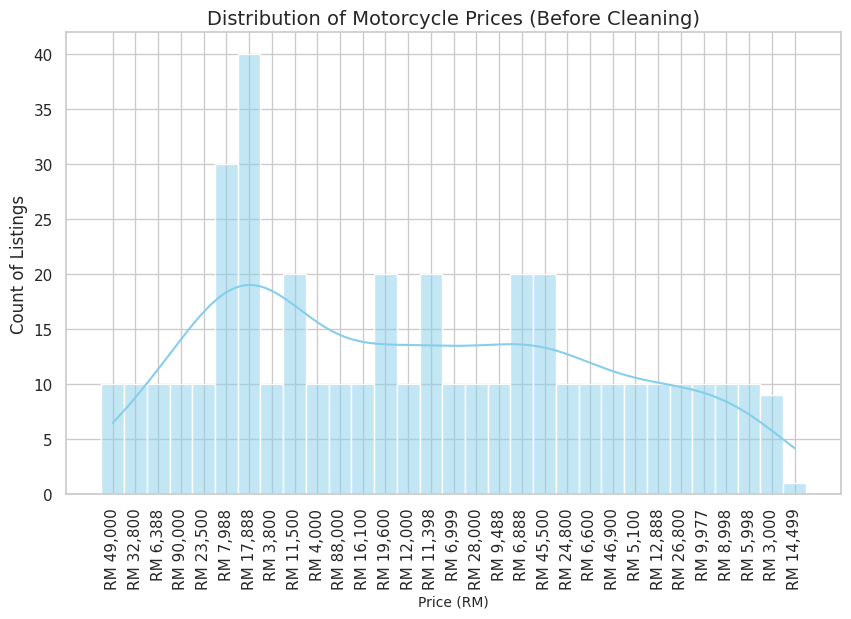

In [ ]:
# Data visualization before cleaning and transform for price
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, bins=20, color='skyblue')

plt.title('Distribution of Motorcycle Prices (Before Cleaning)', fontsize=14)
plt.xlabel('Price (RM)', fontsize=10)
plt.ylabel('Count of Listings', fontsize=12)

# Make x-axis labels vertical
plt.xticks(rotation=90)

plt.show()


In [ ]:
import pandas as pd
import re

df = pd.read_csv('mudah_motorcycles_full.csv')

# Clean price
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('RM', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Standardise product name
df['Product Name'] = df['Product Name'].str.strip().str.lower()

# Remove Price patterns (e.g., RM1200) inside the name
df['Product Name'] = df['Product Name'].apply(
    lambda x: re.sub(r'RM\s?\d[\d,]*', '', x, flags=re.IGNORECASE).strip()
)

# Remove Emojis
# This keeps only standard characters and numbers, removing icons
df['Product Name'] = df['Product Name'].apply(
    lambda x: x.encode('ascii', 'ignore').decode('ascii').strip()
)


#categorical to numerical
df['Seller Type Num'] = df['Seller Type'].map({
    'Individual': 0,
    'Company': 1
})

df['Condition Num'] = df['Condition'].map({
    'Used': 0,
    'New': 1
})

df['Region Num'], region_mapping = pd.factorize(df['Region'])


# Convert manufactured year
df['Manufactured Year'] = pd.to_numeric(df['Manufactured Year'], errors='coerce')

# Handle missing values
df = df.dropna(subset=['Price'])
df['Condition'] = df['Condition'].fillna('Unknown')
df['Region'] = df['Region'].fillna('Unknown')
df['Manufactured Year'] = df['Manufactured Year'].fillna(
    int(df['Manufactured Year'].median())
)



In [ ]:
promo_phrases = [
    r'new year sales?', r'year end sales?', r'sales?',
    r'promo', r'promotion', r'full loan',
    r'low deposit', r'offer', r'stock ready'
]

def clean_product_name(name):
    name = name.lower()
    for phrase in promo_phrases:
        name = re.sub(phrase, '', name)
    return name.strip()

def get_first_alpha_word(name):
    for w in name.split():
        if re.match("^[A-Za-z]+", w):
            return w
    return "Unknown"

df['Brand'] = (
    df['Product Name']
    .apply(clean_product_name)
    .apply(get_first_alpha_word)
    .str.title()   # make Brand look nice
)

#changing to numerical
df['Brand Num'], brand_mapping = pd.factorize(df['Brand'])
brand_map_df = pd.DataFrame({
    'Brand': brand_mapping,
    'Brand Num': range(len(brand_mapping))
})
print("Cleaning complete")

Cleaning complete


In [ ]:

final_cols = [
    'Listing ID',
    'Product Name',
    'Brand',
    'Brand Num',
    'Price',
    'Seller Type',
    'Seller Type Num',
    'Condition',
    'Condition Num',
    'Manufactured Year',
    'Region',
    'Region Num'
]

df_final = df[final_cols]

# 3. Save to CSV
df_final.to_csv(
    'mudah_motorcycles_cleaned.csv',
    index=False,
    encoding='utf-8'
)

# --- VISUALIZE AFTER CLEANING ---
print("---- DATA AFTER CLEANING ----")
display(df_final.head())

# 4. Verification Printouts
print("-" * 30)
print(f"Final Shape: {df_final.shape}")
print("\nColumn Data Types:")
print(df_final.columns)


---- DATA AFTER CLEANING ----


,Listing ID,Product Name,Brand,Brand Num,Price,Seller Type,Seller Type Num,Condition,Condition Num,Manufactured Year,Region,Region Num
0,113553117,honda cbr650r e clutch baru promosi cbr 650 cb...,Honda,0,49000,Company,1,New,1,2025,Kuala Lumpur,0
1,113575774,qjmotor svt 650 x touring adv free 3 box svt650,Qjmotor,1,32800,Company,1,New,1,2025,Kuala Lumpur,0
2,113537369,wmoto xtreme 150 cash back skuter baru promosi,Wmoto,2,6388,Company,1,New,1,2025,Kuala Lumpur,0
3,113682047,2024 honda xadv 750 eruo spec unreg recon adv,Honda,0,90000,Company,1,New,1,2024,Selangor,1
4,113681889,yamaha xmax forza sym elegan,Yamaha,3,23500,Company,1,Used,0,2024,Johor,2


------------------------------
Final Shape: (400, 12)

Column Data Types:
Index(['Listing ID', 'Product Name', 'Brand', 'Brand Num', 'Price',
       'Seller Type', 'Seller Type Num', 'Condition', 'Condition Num',
       'Manufactured Year', 'Region', 'Region Num'],
      dtype='object')


# **Data Visualization**

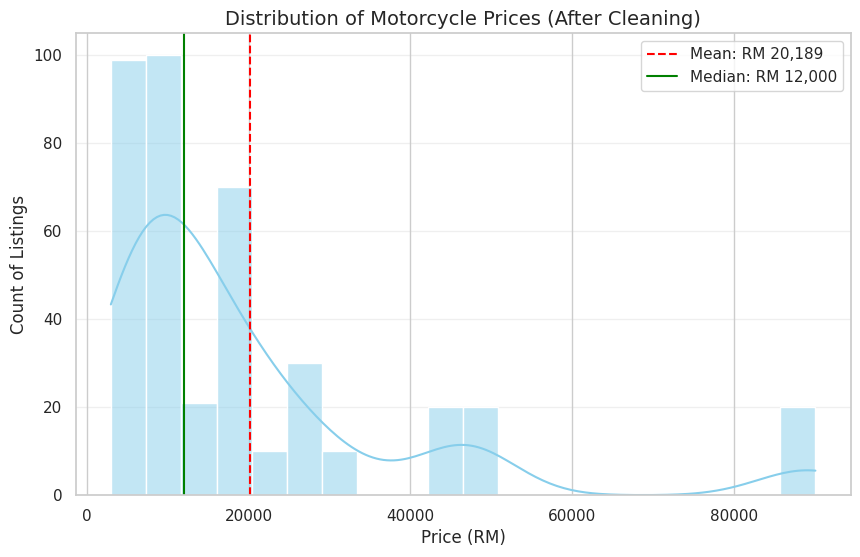

In [ ]:
# Histogram of price after cleaning and transform
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df_final['Price'], kde=True, bins=20, color='skyblue')

# Add Mean and Median lines
mean_price = df_final['Price'].mean()
median_price = df_final['Price'].median()

plt.axvline(mean_price, color='red', linestyle='--', label=f'Mean: RM {mean_price:,.0f}')
plt.axvline(median_price, color='green', linestyle='-', label=f'Median: RM {median_price:,.0f}')

# Labels and Title
plt.title('Distribution of Motorcycle Prices (After Cleaning)', fontsize=14)
plt.xlabel('Price (RM)', fontsize=12)
plt.ylabel('Count of Listings', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
# Descriptive statistics for price after cleaning
price_stats = df_final['Price'].describe()
print(price_stats)


count      400.000000
mean     20189.347500
std      20012.347238
min       3000.000000
25%       7988.000000
50%      12000.000000
75%      23825.000000
max      90000.000000
Name: Price, dtype: float64


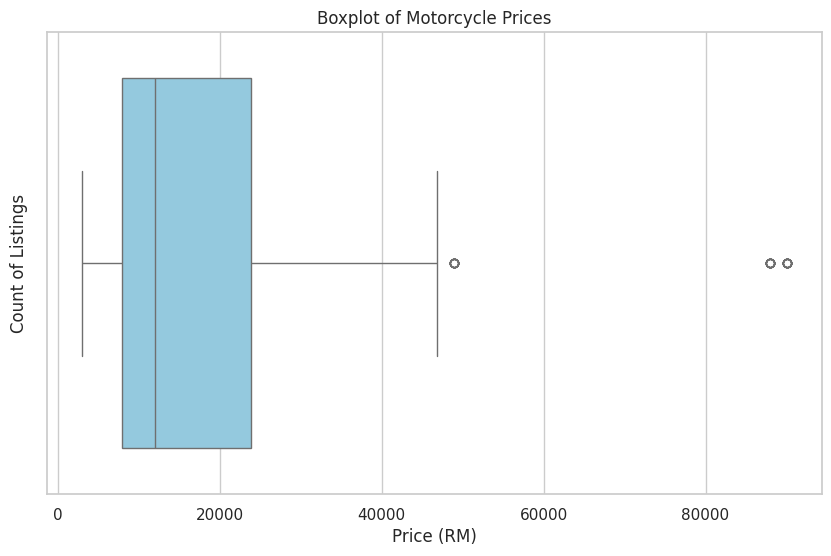

In [ ]:
# Boxplot of price
plt.figure(figsize=(10, 6))
plt.title('Boxplot of Motorcycle Prices')
plt.xlabel('Price (RM)')
plt.ylabel('Count of Listings')
sns.boxplot(x=df_final['Price'], color='skyblue')
plt.show()

In [ ]:
brand_count = (
    df_final
    .groupby('Brand')
    .size()
    .reset_index(name='Total Listings')
    .sort_values(by='Total Listings', ascending=False)
    .reset_index(drop=True)
)

print(brand_count)

        Brand  Total Listings
0      Yamaha              80
1       Honda              40
2        Voge              30
3     Qjmotor              30
4       Wmoto              30
5        Moda              20
6          Qj              20
7       Benda              20
8     Scooter              20
9       Motor              19
10      Aveta              10
11    Benelli              10
12     Harley              10
13   Kawasaki              10
14  Lambretta              10
15         Lc              10
16        New              10
17        Sym              10
18       Used              10
19     Suzuki               1


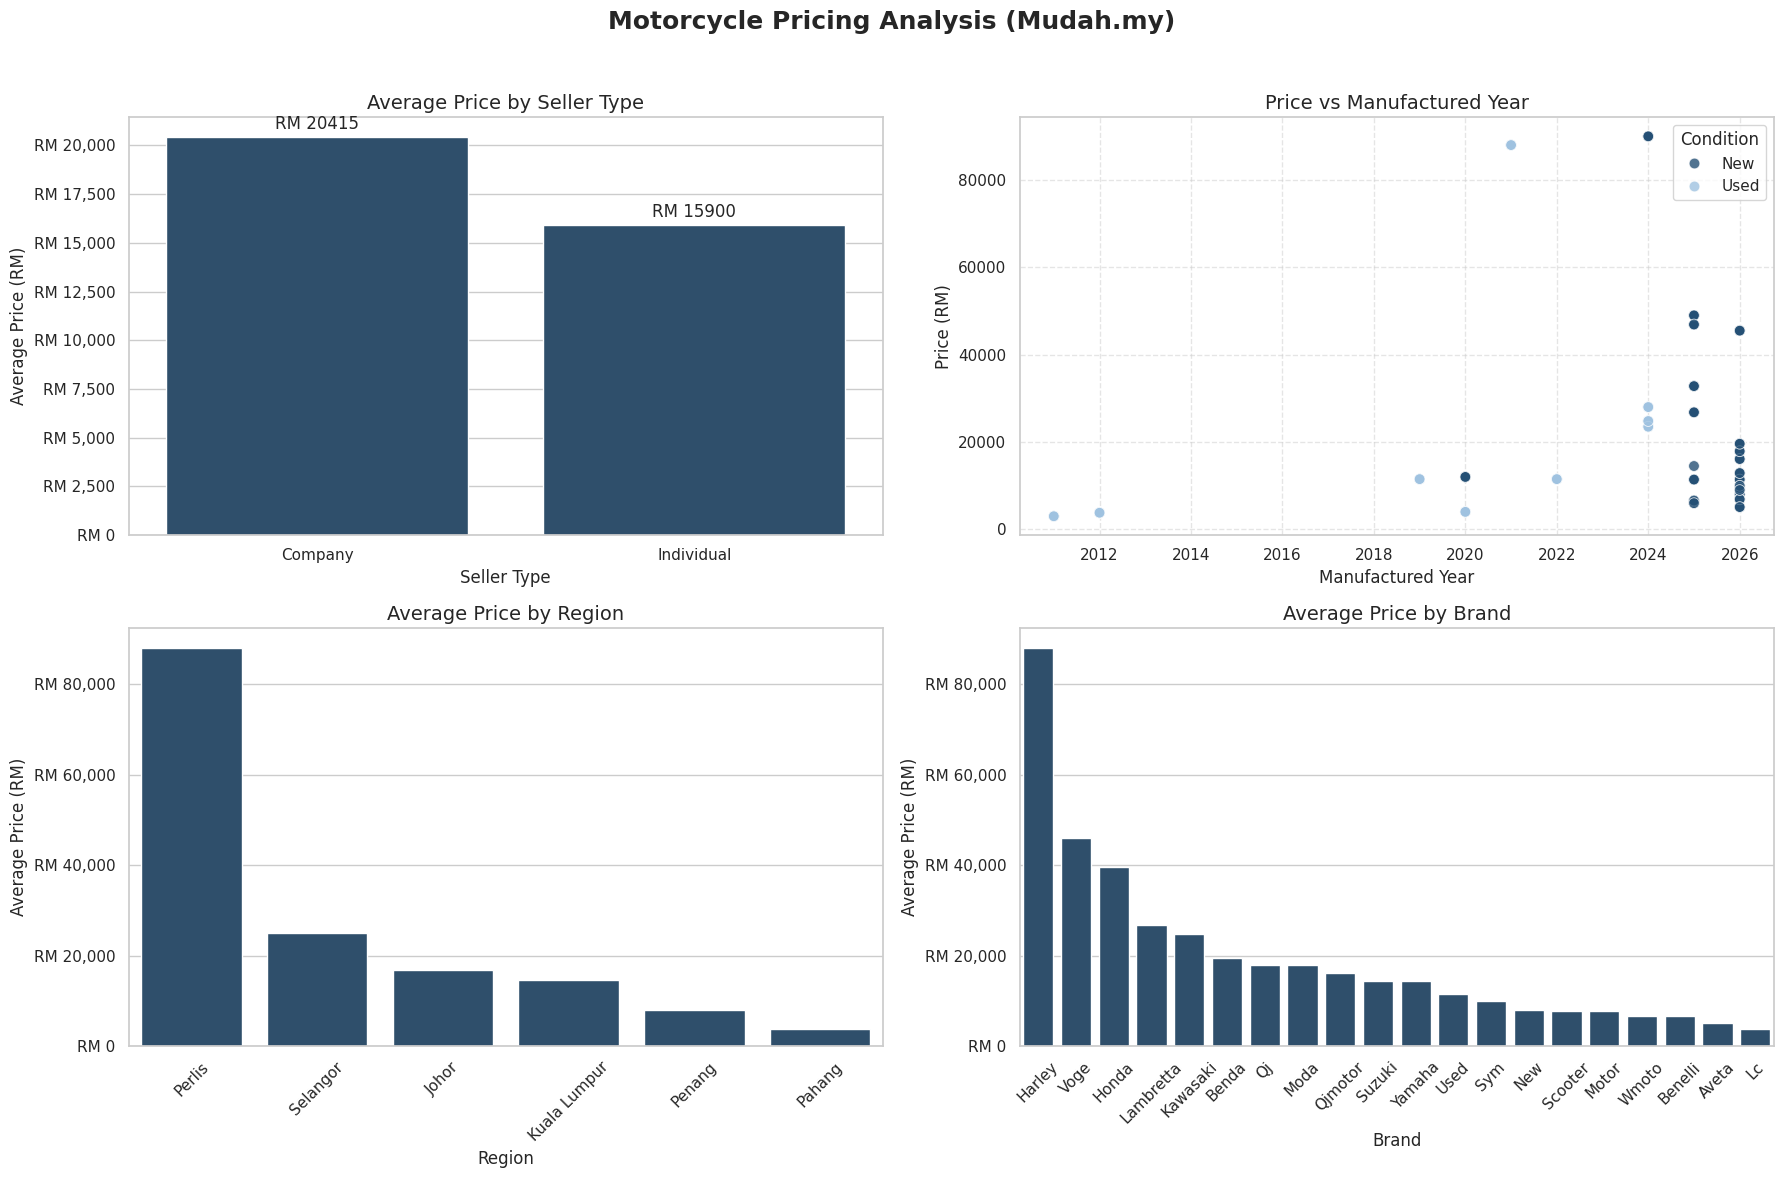

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    'Motorcycle Pricing Analysis (Mudah.my)',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

# GRAPH 1 (Top-Left): Average Price by Seller Type (Soft Blue)
sns.barplot(
    data=df_final,
    x='Seller Type',
    y='Price',
    estimator='mean',
    errorbar=None,
    color='#255075',
    ax=axes[0, 0]
)

axes[0, 0].set_title('Average Price by Seller Type', fontsize=14)
axes[0, 0].set_ylabel('Average Price (RM)', fontsize=12)
axes[0, 0].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'RM {x:,.0f}')
)

for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='RM %.0f', padding=3)


# GRAPH 2 (Top-Right): Price vs Manufactured Year
# Identify unique conditions
conditions = df_final['Condition'].unique()
# Map them to two blue colors
condition_palette = {
    conditions[0]: '#255075',  # dark blue
    conditions[1]: '#9fc2e0'   # light blue
}

sns.scatterplot(
    data=df_final,
    x='Manufactured Year',
    y='Price',
    hue='Condition',
    palette=condition_palette,
    ax=axes[0, 1],
    legend='auto',
    s=60,
    alpha=0.8
)
axes[0, 1].set_title('Price vs Manufactured Year', fontsize=14)
axes[0, 1].set_xlabel('Manufactured Year', fontsize=12)
axes[0, 1].set_ylabel('Price (RM)', fontsize=12)
axes[0, 1].grid(True, which="both", ls="--", alpha=0.5)


# GRAPH 3 (Bottom-Left): Average Price by Region
region_order = (
    df_final
    .groupby('Region')['Price']
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.barplot(
    data=df_final,
    x='Region',
    y='Price',
    order=region_order,
    estimator='mean',
    errorbar=None,
    color='#255075',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Average Price by Region', fontsize=14)
axes[1, 0].set_ylabel('Average Price (RM)', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'RM {x:,.0f}')
)


# GRAPH 4 (Bottom-Right): Average Price by Brand
brand_order = (
    df_final
    .groupby('Brand')['Price']
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.barplot(
    data=df_final,
    x='Brand',
    y='Price',
    order=brand_order,
    estimator='mean',
    errorbar=None,
    color='#255075',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Average Price by Brand', fontsize=14)
axes[1, 1].set_ylabel('Average Price (RM)', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'RM {x:,.0f}')
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
